In [1]:
from pylab import *

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.4
Plasticnet version  0.1.13
macOS-15.5-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
old_base_sim_dir=f"sims-2025-05-31 mu_c sigma_c blur"
base_sim_dir=f"sims-2025-06-03 mu_c"
if not os.path.exists(base_sim_dir):
    print("new")
    os.mkdir(base_sim_dir)
print(base_sim_dir)


sims-2025-06-03 mu_c


In [4]:
def default_post(number_of_neurons):
    post=pn.neurons.linear_neuron(number_of_neurons)
    post+=pn.neurons.process.sigmoid(0,50)
    return post

def default_bcm(pre,post,orthogonalization=True):
    c=pn.connections.BCM(pre,post,[-.01,.01],[.1,.2])
    
    if orthogonalization:
        c+=pn.connections.process.orthogonalization(10*minute)

    c.eta=2e-6
    c.tau=15*pn.minute   

    return c

In [5]:
def deficit(blur=[2.5,-1],noise=[0.1,0.1],rf_size=19,
            eta=2e-6,
           number_of_neurons=10,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,
           total_time=8*day,
           save_interval=1*hour):


    print("sigma_c",sigma_c)
    
    im=[]
    for b in blur:
        if b<0:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
        else:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'blur','size':b},
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                   rf_size=rf_size,
                                                sigma_r=0,
                                                sigma_c=0,
                                       verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],rf_size=rf_size,
                                other_channel=pre1,
                                    mu_r=mu_r,mu_c=mu_c,
                                    sigma_r=sigma_r,sigma_c=sigma_c,
                                verbose=False)

    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])

    sigma=noise
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    sim=pn.simulation(total_time)
    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi,
                            )

    return sim,[pre,post],[c]


@ray.remote
def run_one_deficit(params,run=True,overwrite=False):
    import plasticnet as pn
    noise,blur,mu_c,mu_r,sigma_c,sigma_r,number_of_neurons,sfname=(
                                params.noise,
                                params.blur,
                                params.mu_c,
                                params.mu_r,
                                params.sigma_c,
                                params.sigma_r,
                                params.number_of_neurons,
                                params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                 noise=noise,blur=blur,
                 mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,) 


    if run:
        seq.run(display_hash=False)
        pn.save(sfname,seq) 
    
    return sfname
    

In [6]:
number_of_neurons=20
eta=1e-6
number_of_processes=8
ray.init(num_cpus=number_of_processes)

2025-06-04 08:09:32,191	INFO worker.py:1852 -- Started a local Ray instance.


Python version:,3.12.6
Ray version:,2.44.1


(pid=89218) Splikes version  0.1.4
(pid=89218) Plasticnet version  0.1.13
(run_one_deficit pid=89218) sigma_c 0
(run_one_deficit pid=89218) [
(run_one_deficit pid=89218) .] Sequence Time Elapsed...1 m, 30.13 s


## Running one with $\mu_c=20$

In [7]:
p=Struct()
p.number_of_neurons=number_of_neurons
p.mu_c=20
p.sigma_c=0
p.mu_r=0
p.sigma_r=0
p.blur=[-1,-1]
p.sfname=base_sim_dir+f"/mu_c={p.mu_c}.asdf"

p.noise=(.1,.1)


In [8]:
results = [run_one_deficit.remote(p,overwrite=True)]
sfnames=ray.get(results)

In [9]:
sfnames

['sims-2025-06-03 mu_c/mu_c=20.asdf']

In [10]:
sfname=sfnames[0]
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

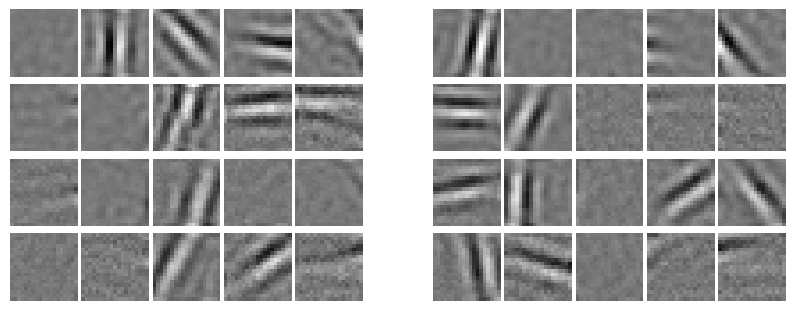

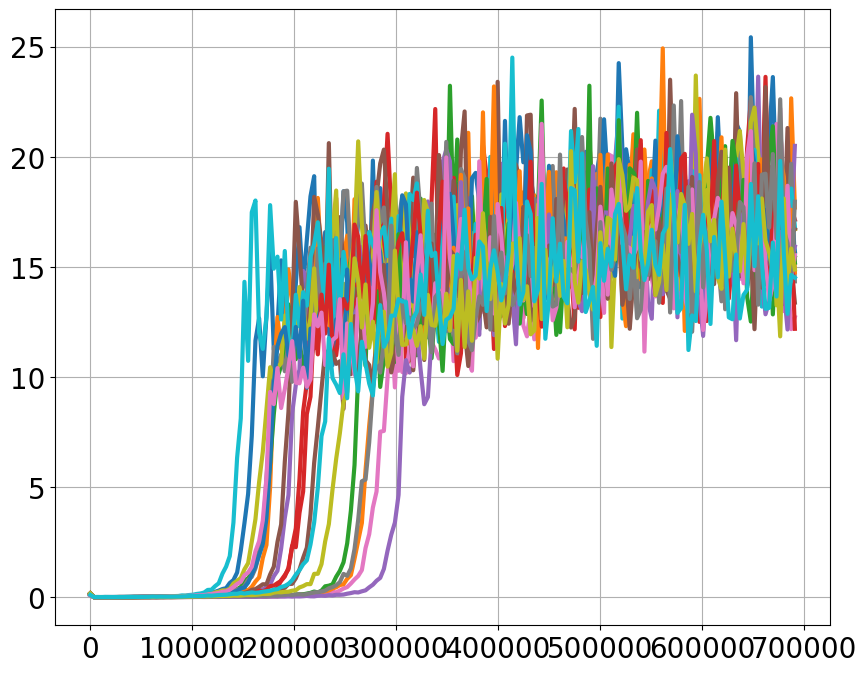

In [11]:
figure()
ims=R.W_image()

for c in range(2):
    subplot(1,2,c+1)
    imshow(ims[c],cmap=cm.gray)
    grid(None)
    axis('off')

figure()
plot(R.t,R.θ);

In [12]:
R.ODI.shape

(193, 20)

(array([6., 2., 1., 0., 1., 0., 1., 0., 1., 8.]),
 array([-0.96492412, -0.77362224, -0.58232037, -0.39101849, -0.19971662,
        -0.00841474,  0.18288713,  0.37418901,  0.56549088,  0.75679276,
         0.94809463]),
 <BarContainer object of 10 artists>)

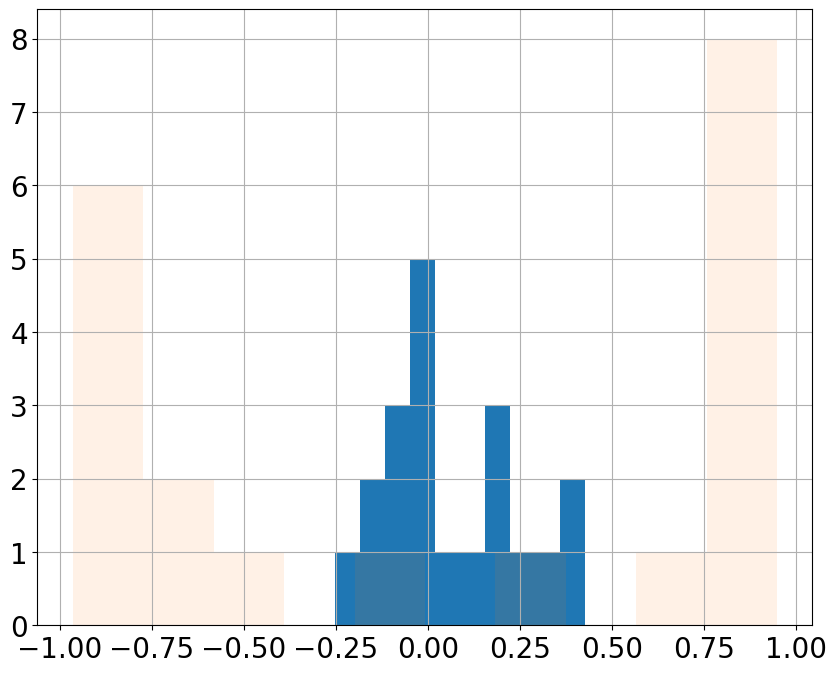

In [13]:
hist(R.ODI[0,:])
hist(R.ODI[-1,:],alpha=0.1)

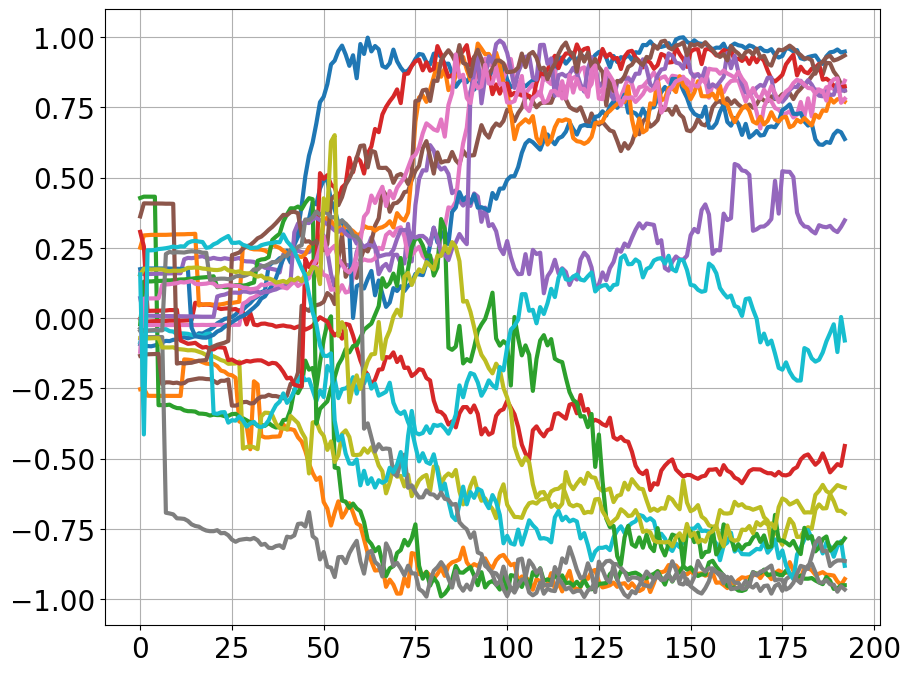

In [14]:
plot(R.ODI);

In [15]:
R.ODI.shape

(193, 20)

## Measure bimodality -- useful or not?

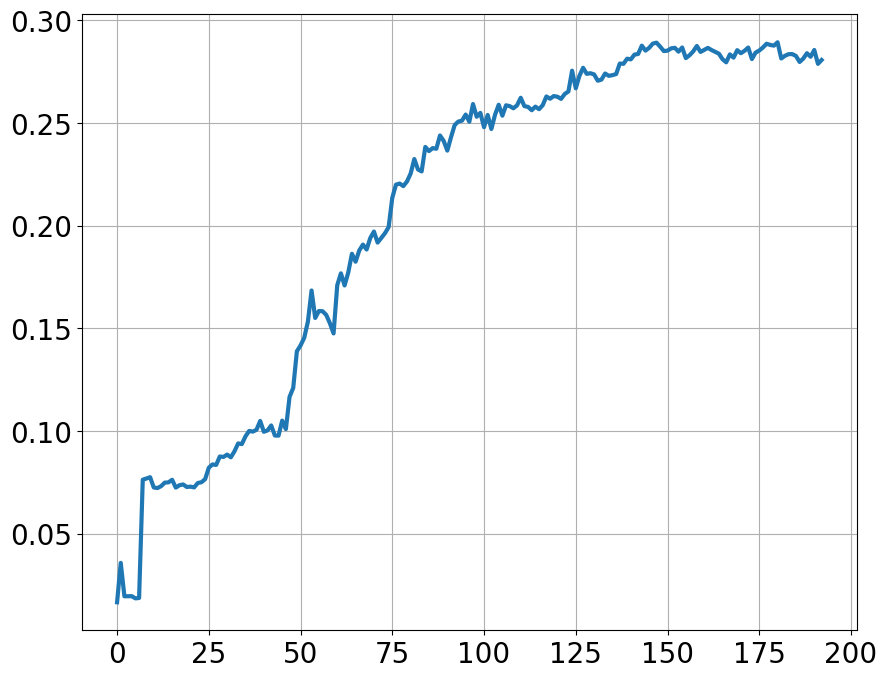

In [18]:
y=R.ODI
y=y-y.min(axis=1,keepdims=True)
BCM_R=1/3*(y**3).mean(axis=1)-1/4*(y**2).mean(axis=1)**2
plot(BCM_R)

## Running one with $\mu_c=30$ -- does it make any difference?

- Completely monocular with $\mu_c=30$
- Completely monocular with $\mu_c=25$
- Mostly monocular with $\mu_c=20$

In [39]:
p=Struct()
p.number_of_neurons=number_of_neurons
p.mu_c=25
p.sigma_c=0
p.mu_r=0
p.sigma_r=0
p.blur=[-1,-1]
p.sfname=base_sim_dir+f"/mu_c={p.mu_c}.asdf"

p.noise=(.1,.1)


In [40]:
results = [run_one_deficit.remote(p)]
sfnames=ray.get(results)

In [41]:
sfnames

['sims-2025-06-03 mu_c/mu_c=25.asdf']

In [42]:
sfname=sfnames[0]
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

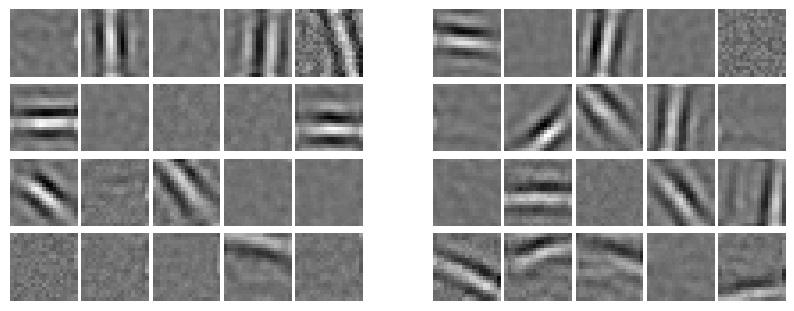

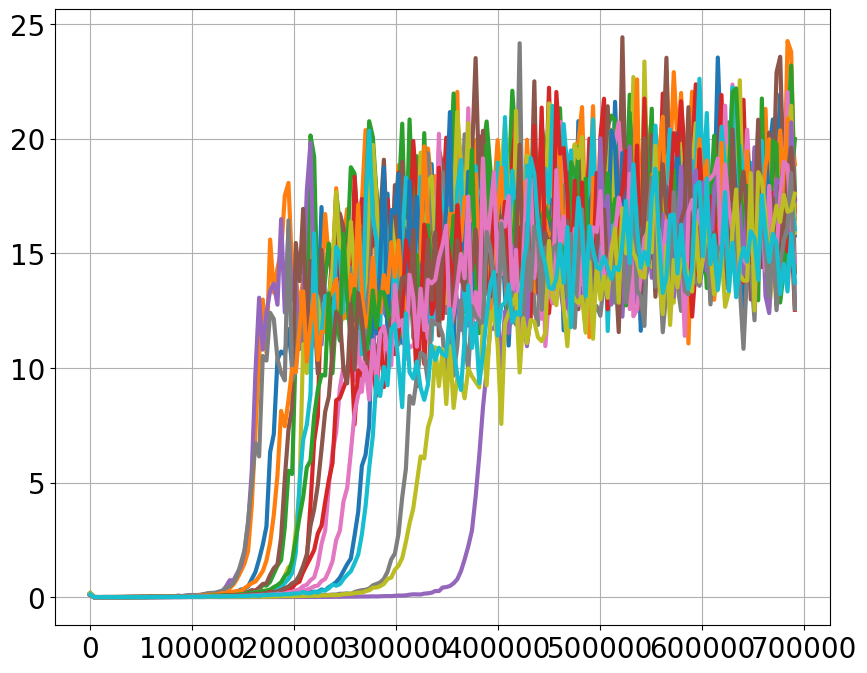

In [43]:
figure()
ims=R.W_image()

for c in range(2):
    subplot(1,2,c+1)
    imshow(ims[c],cmap=cm.gray)
    grid(None)
    axis('off')

figure()
plot(R.t,R.θ);

In [44]:
R.ODI.shape

(193, 20)

(array([ 8.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 12.]),
 array([-0.96855068, -0.77291155, -0.57727242, -0.38163329, -0.18599416,
         0.00964497,  0.2052841 ,  0.40092323,  0.59656236,  0.79220149,
         0.98784062]),
 <BarContainer object of 10 artists>)

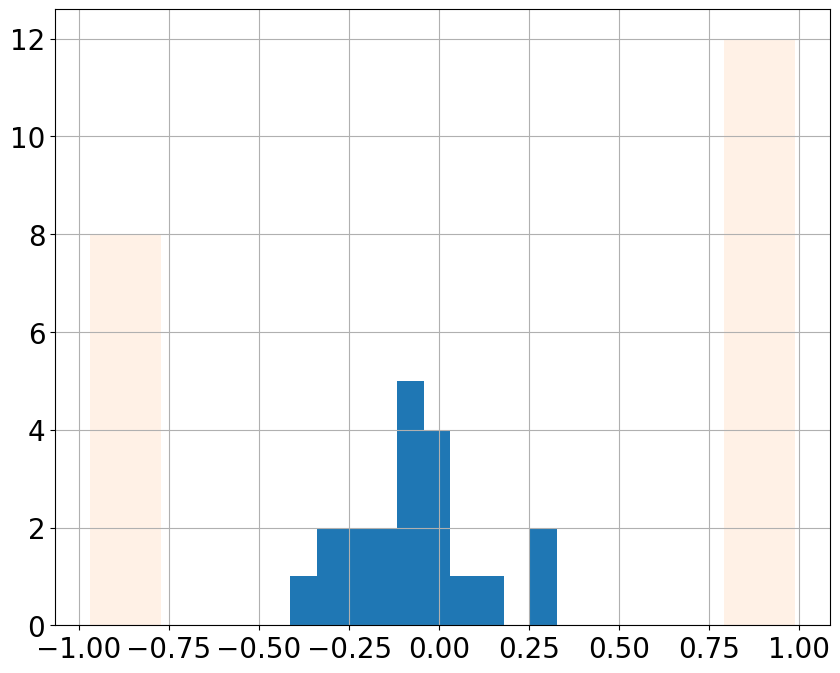

In [45]:
hist(R.ODI[0,:])
hist(R.ODI[-1,:],alpha=0.1)

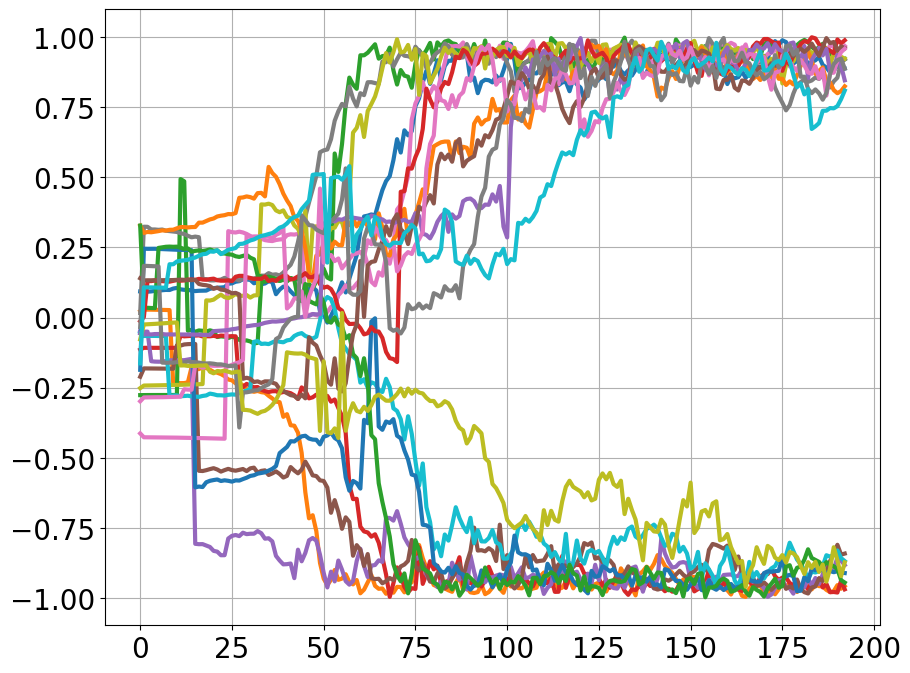

In [46]:
plot(R.ODI);

## Running one with $\mu_c=25$ (monocular) with $\sigma_c=1$

- $\sigma_c=1$ = monocular
- $\sigma_c=3$ = monocular
- $\sigma_c=6$ = monocular
- $\sigma_c=10$ = monocular

In [99]:
p=Struct()
p.number_of_neurons=number_of_neurons
p.mu_c=25
p.sigma_c=10
p.mu_r=0
p.sigma_r=0
p.blur=[-1,-1]
p.sfname=base_sim_dir+f"/mu_c={p.mu_c} sigma_c={p.sigma_c}.asdf"

p.noise=(.1,.1)


In [102]:
results = [run_one_deficit.remote(p,overwrite=True)]
sfnames=ray.get(results)

In [103]:
sfnames

['sims-2025-06-03 mu_c/mu_c=25 sigma_c=10.asdf']

In [104]:
sfname=sfnames[0]
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

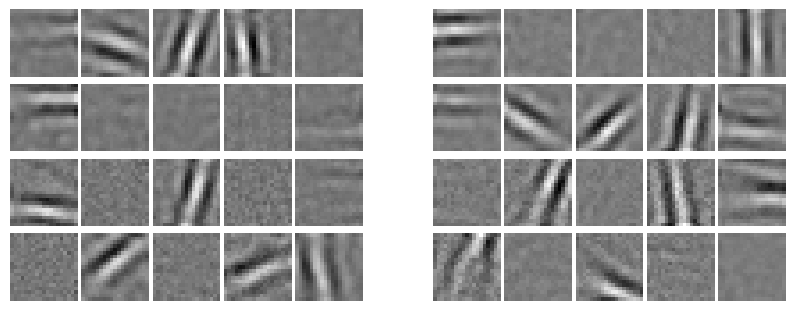

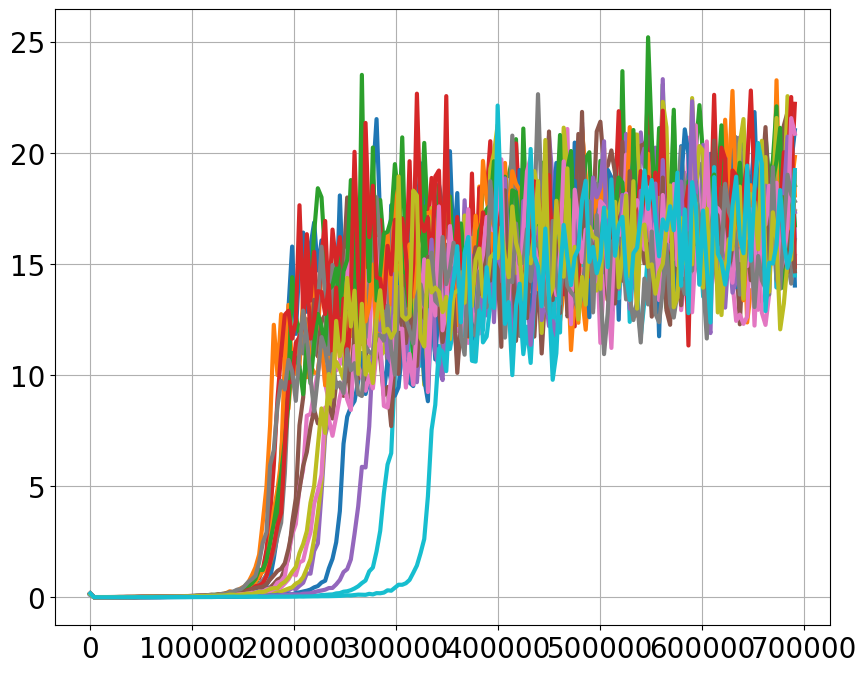

In [105]:
figure()
ims=R.W_image()

for c in range(2):
    subplot(1,2,c+1)
    imshow(ims[c],cmap=cm.gray)
    grid(None)
    axis('off')

figure()
plot(R.t,R.θ);

In [106]:
R.ODI.shape

(193, 20)

(array([8., 0., 0., 1., 0., 0., 0., 2., 1., 8.]),
 array([-0.9714472 , -0.77990965, -0.5883721 , -0.39683455, -0.20529699,
        -0.01375944,  0.17777811,  0.36931566,  0.56085321,  0.75239076,
         0.94392832]),
 <BarContainer object of 10 artists>)

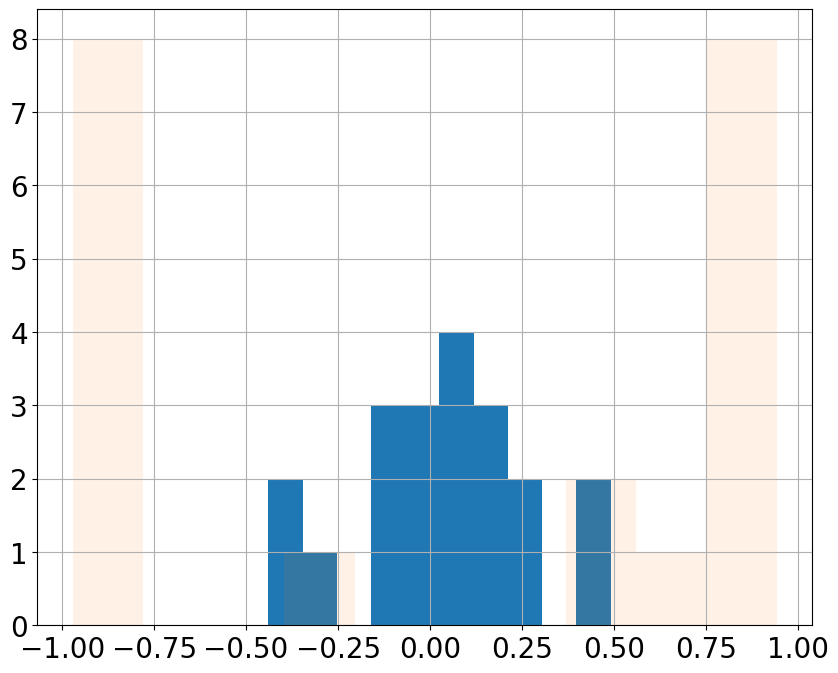

In [107]:
hist(R.ODI[0,:])
hist(R.ODI[-1,:],alpha=0.1)

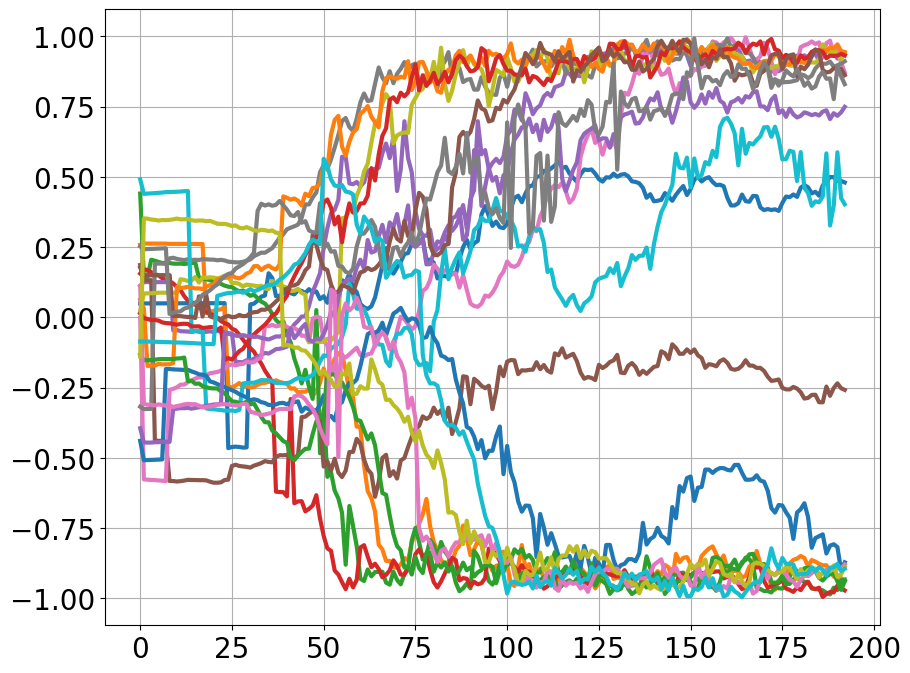

In [108]:
plot(R.ODI);

## Does $\sigma_c$ do anything?  try $\mu_c=0$ with different $\sigma_c$

- $\sigma_c=0$ = binocular
- $\sigma_c=3$ = 
- $\sigma_c=6$ = 
- $\sigma_c=30$ = monocular


In [125]:
p=Struct()
p.number_of_neurons=number_of_neurons
p.mu_c=0
p.sigma_c=20
p.mu_r=0
p.sigma_r=0
p.blur=[-1,-1]
p.sfname=base_sim_dir+f"/mu_c={p.mu_c} sigma_c={p.sigma_c}.asdf"

p.noise=(.1,.1)


In [126]:
results = [run_one_deficit.remote(p,overwrite=True)]
sfnames=ray.get(results)

In [127]:
sfnames

['sims-2025-06-03 mu_c/mu_c=0 sigma_c=20.asdf']

In [128]:
sfname=sfnames[0]
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

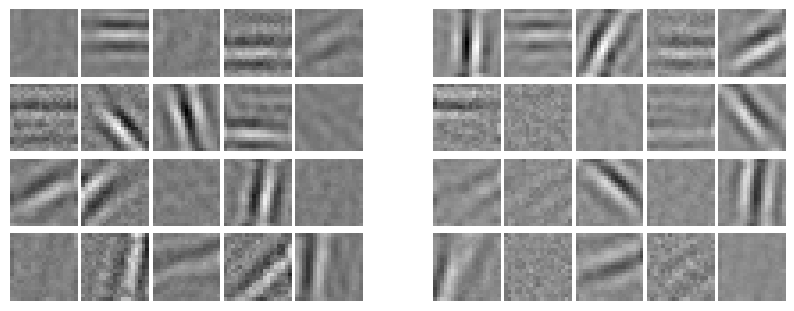

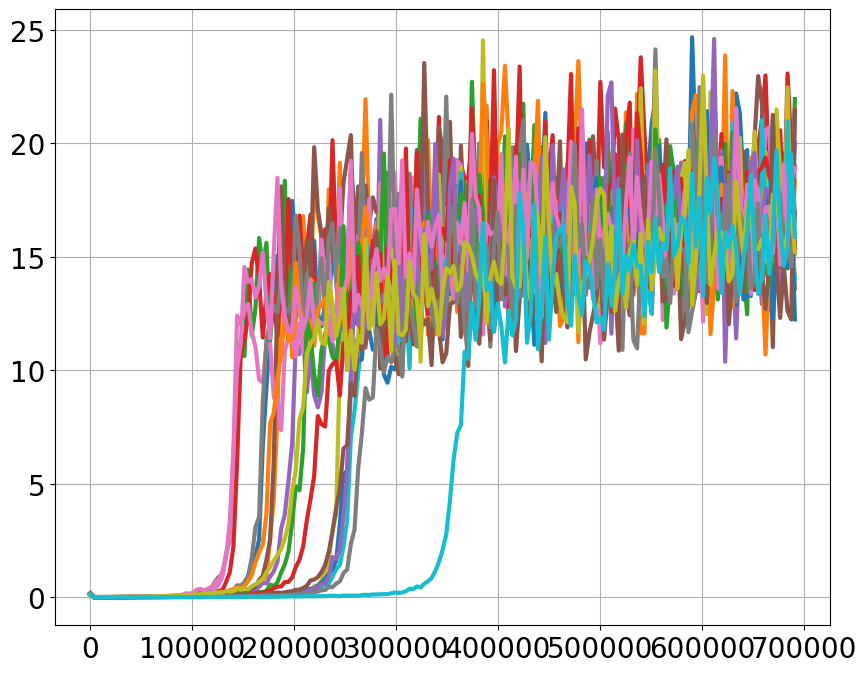

In [129]:
figure()
ims=R.W_image()

for c in range(2):
    subplot(1,2,c+1)
    imshow(ims[c],cmap=cm.gray)
    grid(None)
    axis('off')

figure()
plot(R.t,R.θ);

In [130]:
R.ODI.shape

(193, 20)

(array([5., 2., 1., 1., 3., 1., 0., 1., 1., 5.]),
 array([-0.9427784 , -0.7548998 , -0.5670212 , -0.3791426 , -0.191264  ,
        -0.00338541,  0.18449319,  0.37237179,  0.56025039,  0.74812899,
         0.93600758]),
 <BarContainer object of 10 artists>)

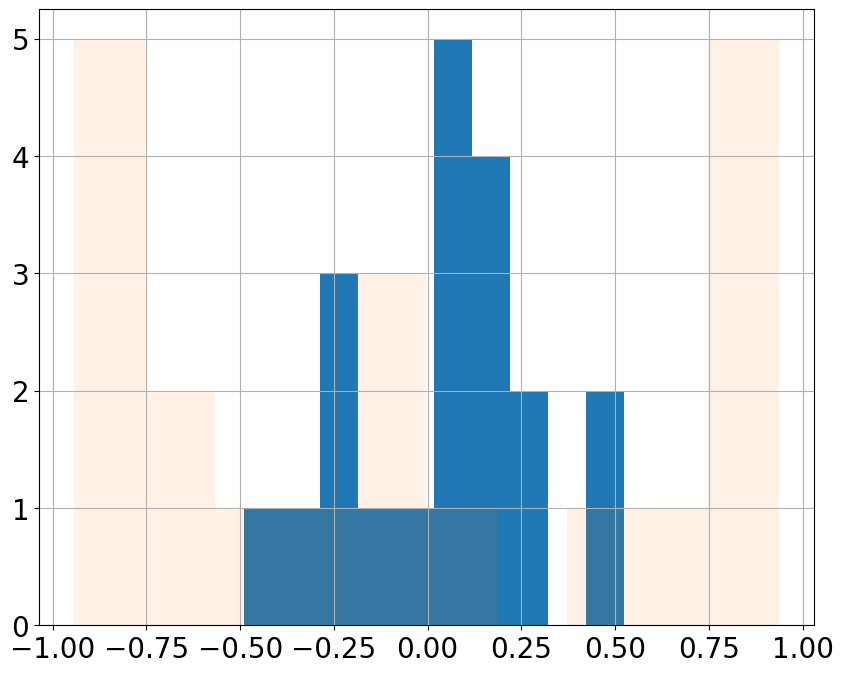

In [131]:
hist(R.ODI[0,:])
hist(R.ODI[-1,:],alpha=0.1)

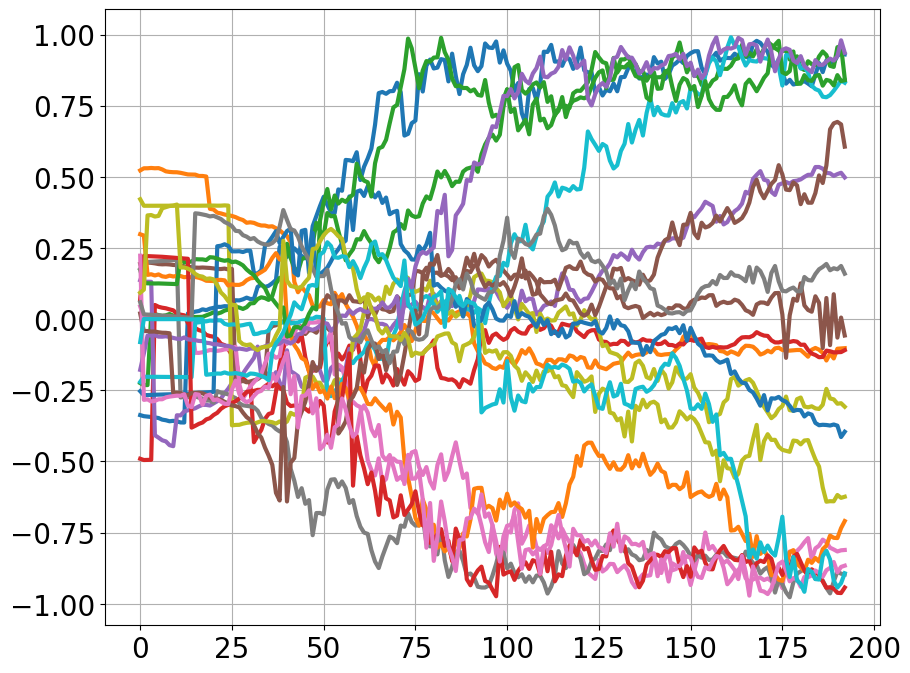

In [132]:
plot(R.ODI);

## try many sigma_c values with mu=0

In [144]:
sigma_c_mat=linspace(0,30,13)
sigma_c_mat

array([ 0. ,  2.5,  5. ,  7.5, 10. , 12.5, 15. , 17.5, 20. , 22.5, 25. ,
       27.5, 30. ])

In [145]:
do_params=[]
for sigma_c in sigma_c_mat:
    p=Struct()
    p.number_of_neurons=number_of_neurons
    p.mu_c=0
    p.sigma_c=sigma_c
    p.mu_r=0
    p.sigma_r=0
    p.blur=[-1,-1]
    p.sfname=base_sim_dir+f"/mu_c={p.mu_c} sigma_c={p.sigma_c}.asdf"
    
    p.noise=(.1,.1)

    do_params.append(p)


results = [run_one_deficit.remote(p,overwrite=True) for p in do_params]
sfnames=ray.get(results)
   

Text(0, 0.5, 'ODI')

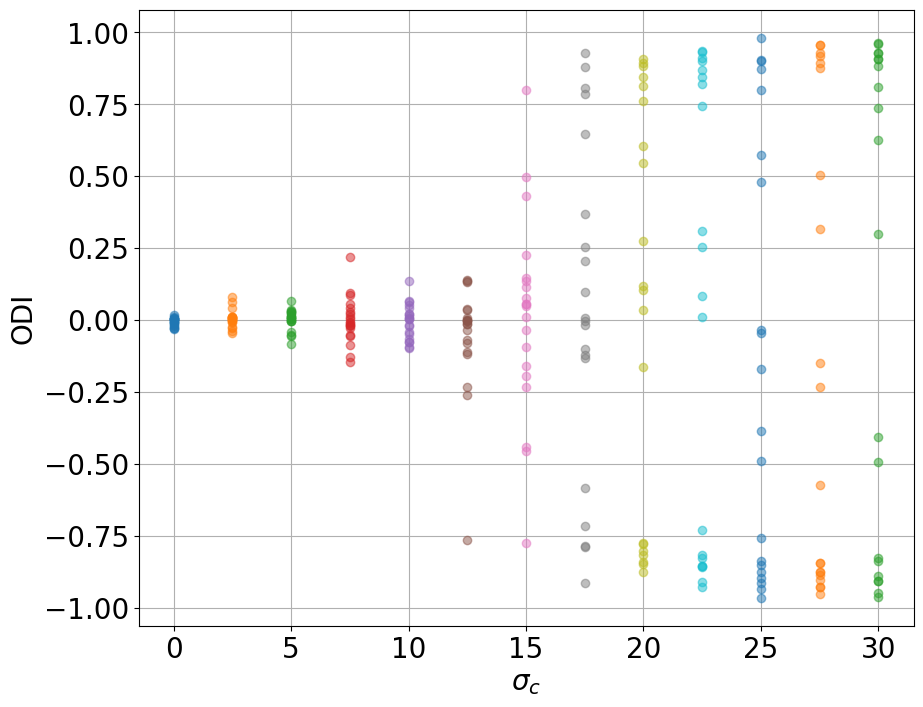

In [146]:

_S=Storage()
for sigma_c,sfname in zip(sigma_c_mat,sfnames):
    
    R=Results(sfname)

    plot(sigma_c*ones(R.ODI.shape[-1]),R.ODI[-1,:],'o',alpha=0.5)

xlabel(r'$\sigma_c$')
ylabel('ODI')

 

## Same thing with mu_c and sigma_c=0

- Crazy!  with larger sigma, the ODI is more binocular with less variation!

In [147]:
mu_c_mat=linspace(0,30,13)
mu_c_mat

array([ 0. ,  2.5,  5. ,  7.5, 10. , 12.5, 15. , 17.5, 20. , 22.5, 25. ,
       27.5, 30. ])

In [150]:
do_params=[]
for mu_c in mu_c_mat:
    p=Struct()
    p.number_of_neurons=number_of_neurons
    p.mu_c=mu_c
    p.sigma_c=6
    p.mu_r=0
    p.sigma_r=0
    p.blur=[-1,-1]
    p.sfname=base_sim_dir+f"/mu_c={p.mu_c} sigma_c={p.sigma_c}.asdf"
    
    p.noise=(.1,.1)

    do_params.append(p)


results = [run_one_deficit.remote(p,overwrite=True) for p in do_params]
sfnames=ray.get(results)
   

Text(0, 0.5, 'ODI')

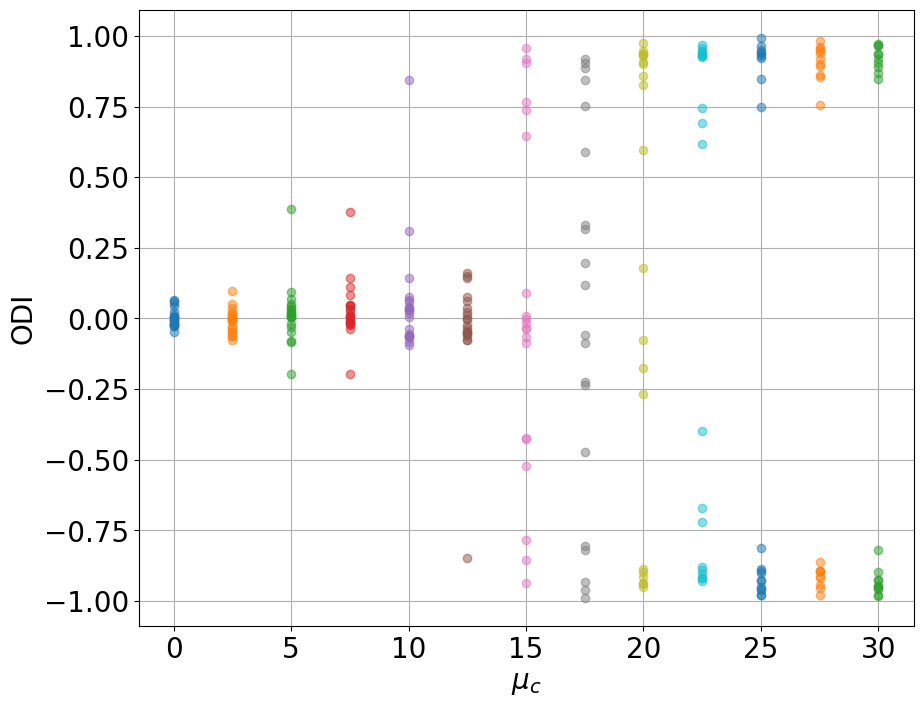

In [151]:

_S=Storage()
for mu_c,sfname in zip(mu_c_mat,sfnames):
    
    R=Results(sfname)

    plot(mu_c*ones(R.ODI.shape[-1]),R.ODI[-1,:],'o',alpha=0.5)

xlabel(r'$\mu_c$')
ylabel('ODI')

 

- with sigma_c=0: 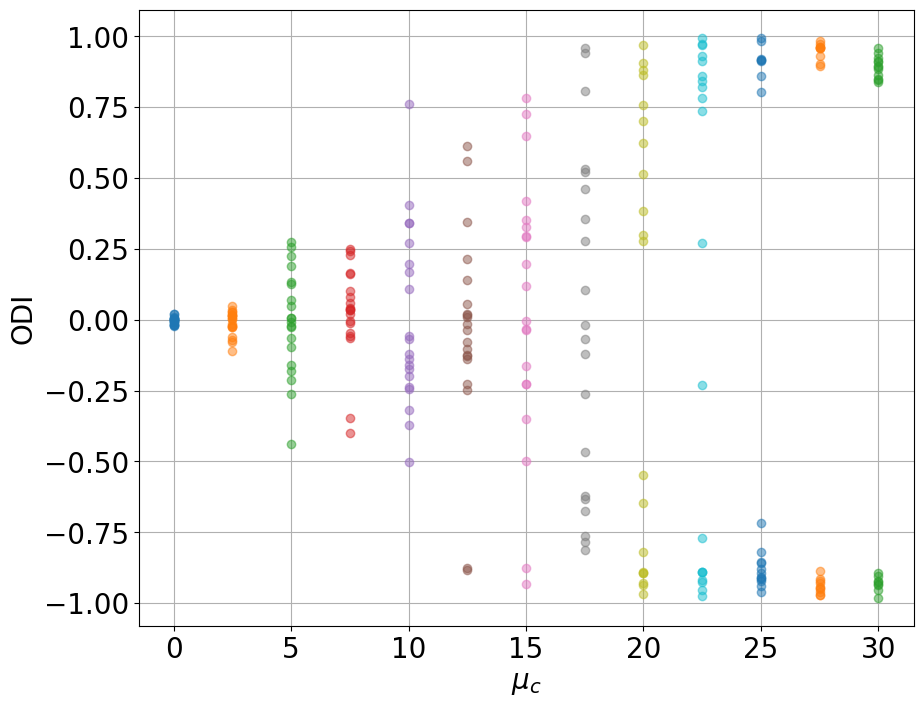

## Now do the effect of blur -1 vs 0 vs 1, etc...